**LOAD THE IBM TELCO CHURN DATASET**

In [1]:
import pandas as pd
import numpy as np

In [23]:
df = pd.read_csv("/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Data loaded successfully")
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Data loaded successfully
Rows : 7043
Columns : 21


**EXPLORE AND UNDERSTAND THE DATASET**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
print(df.columns.tolist())


['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [7]:
categorical_columns = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "Churn"
]

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

 SeniorCitizen
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

 Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

 Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

 PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

 MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

 InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

 OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

 OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

 DeviceProtection
DeviceProtection
No                     3095
Yes                    2422
No intern

In [8]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [9]:
print(df["Churn"].value_counts(normalize="True")*100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**CLEAN AND PREPROCESS THE DATASET**

In [10]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [11]:
print(df["TotalCharges"].unique()[:20])

['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']


In [24]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [25]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [26]:
print("Duplicate Customer IDs:", df["customerID"].duplicated().sum())

Duplicate Customer IDs: 0


In [27]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [28]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [166]:
df.to_csv("customer_churn_cleaned.csv", index=False)

**Exploratory data analysis**

OVERALL CHURN RATE

In [29]:
churn_rate= df["Churn"].mean()*100
print(f"Overall churn rate {churn_rate:.2f}%")

Overall churn rate 26.54%


CHURN BY CONTRACT TYPE

In [59]:
contract_churn =(
    df.groupby("Contract")["Churn"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(contract_churn)


Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

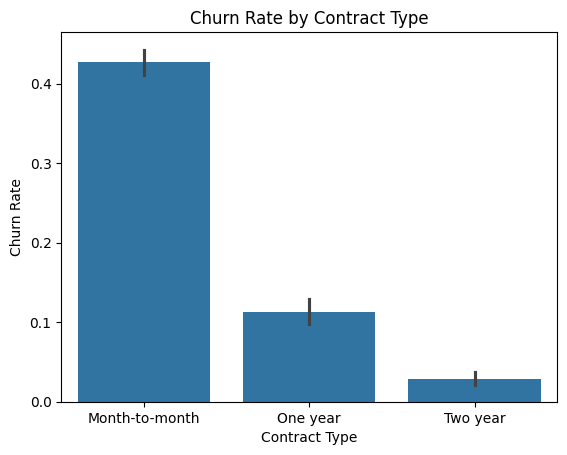

In [62]:
sns.barplot(
    data=df,
    x="Contract",
    y="Churn"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.show()

CHURN BY TENURE

In [33]:
df.groupby("Churn")["tenure"].mean()

,tenure
Churn,
0,37.569965
1,17.979133


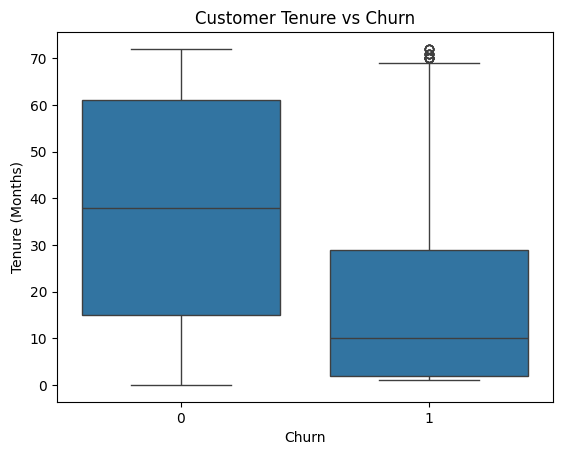

In [34]:
sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

In [35]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

In [37]:
tenure_churn = (
    df.groupby("TenureGroup", observed=True)["Churn"]
    .mean()
    .mul(100)
)

print(tenure_churn)

TenureGroup
0-6 Months      52.937205
7-12 Months     35.886525
13-24 Months    28.710938
25-48 Months    20.388959
49-72 Months     9.513176
Name: Churn, dtype: float64


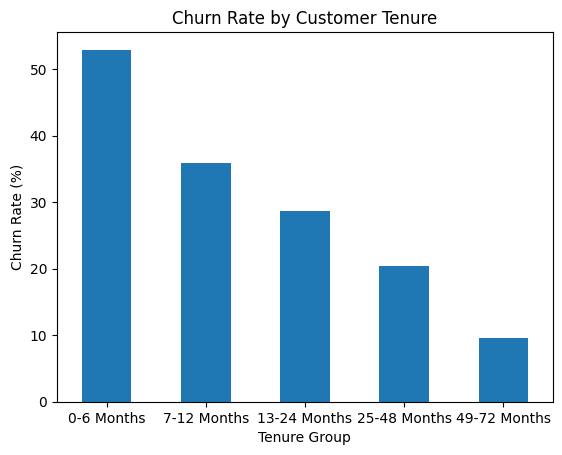

In [38]:
tenure_churn.plot(kind="bar")

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

CHURN BY MONTHLY CHARGES

In [39]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
0,61.265124
1,74.441332


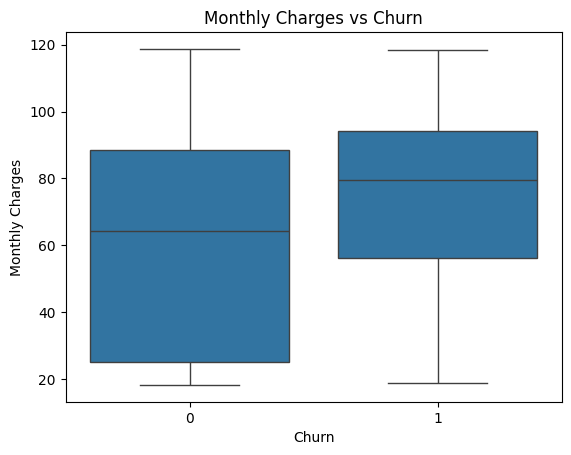

In [40]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

CHURN BY PAYMENT METHOD

In [41]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"].mean().mul(100).sort_values(ascending=False)
)
print(payment_churn)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64


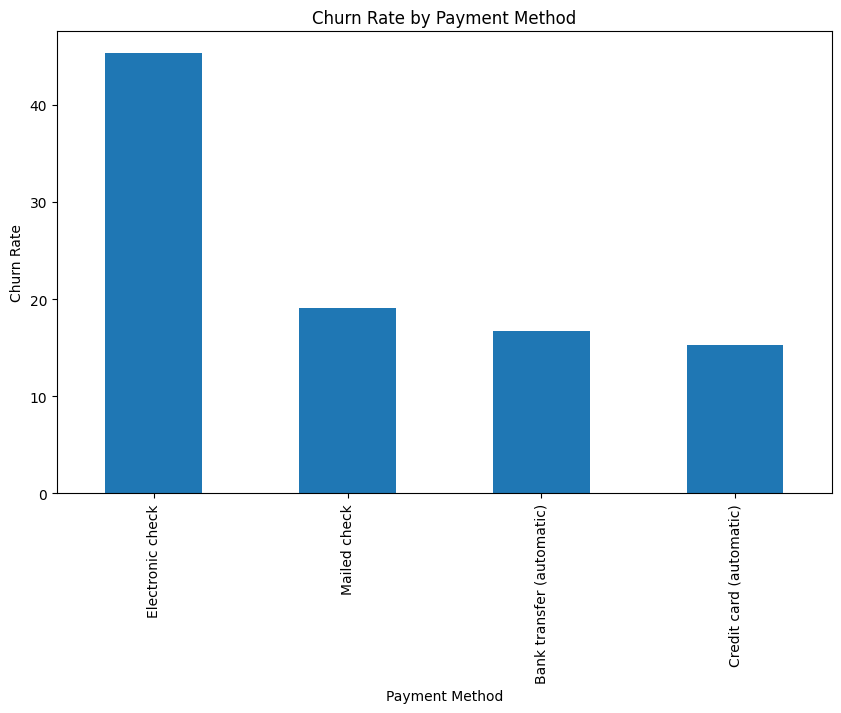

In [42]:
payment_churn.plot(kind="bar", figsize=(10, 6))
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate")
plt.show()

CHURN BY INTERNET SERVICE

In [43]:
internet_churn =(df.groupby("InternetService")["Churn"].mean().mul(100).sort_values(ascending=False))
print(internet_churn)

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64


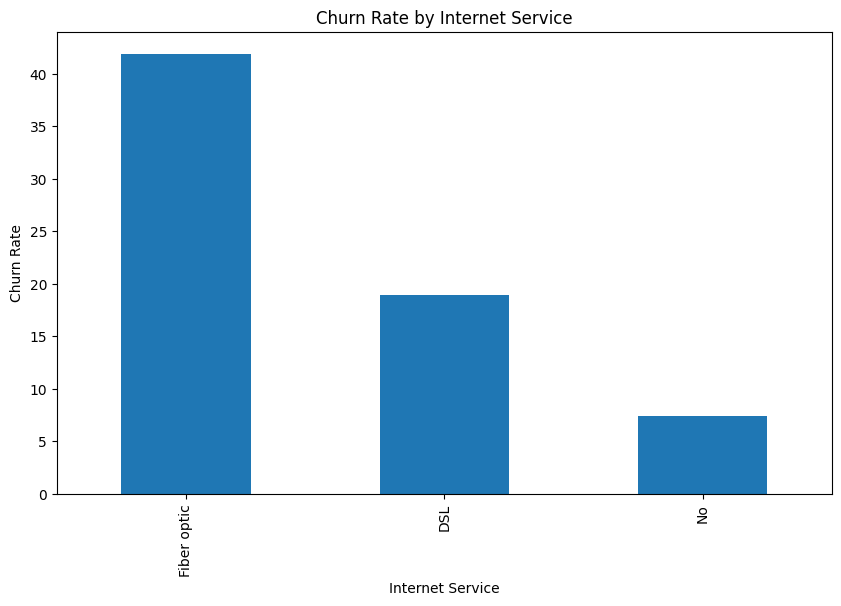

In [44]:
internet_churn.plot(kind="bar",figsize=(10,6))
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate")
plt.show()

CHURN BY TECH SUPPORT

In [46]:
tech_churn = (
    df.groupby("TechSupport")["Churn"]
    .mean()
    .mul(100)
)

print(tech_churn)

TechSupport
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: Churn, dtype: float64


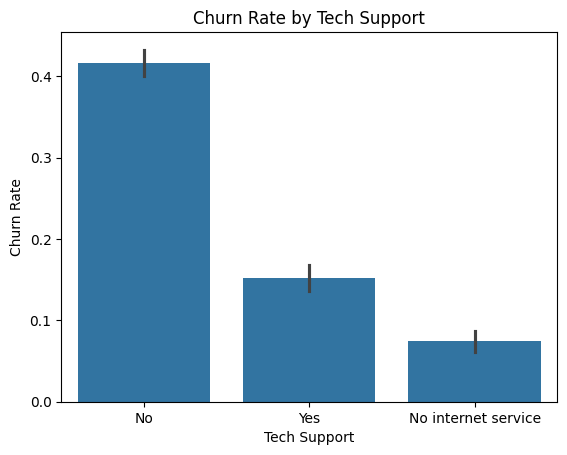

In [48]:
sns.barplot(
    data=df,
    x="TechSupport",
    y="Churn"
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate")
plt.show()

CHURN BY ONLINE SECURITY

In [50]:
security_churn = (
    df.groupby("OnlineSecurity")["Churn"]
    .mean()
    .mul(100)
)

print(security_churn)

OnlineSecurity
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: Churn, dtype: float64


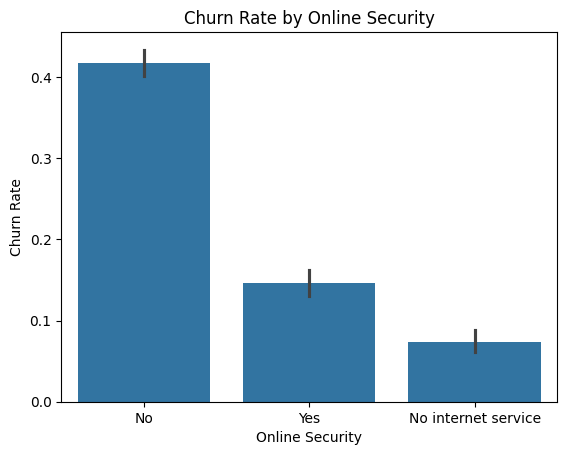

In [51]:
sns.barplot(
    data=df,
    x="OnlineSecurity",
    y="Churn"
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate")
plt.show()

VHURN BY SENIOR CITIZEN

In [53]:
senior_churn = (
    df.groupby("SeniorCitizen")["Churn"]
    .mean()
    .mul(100)
)

print(senior_churn)

SeniorCitizen
0    23.606168
1    41.681261
Name: Churn, dtype: float64


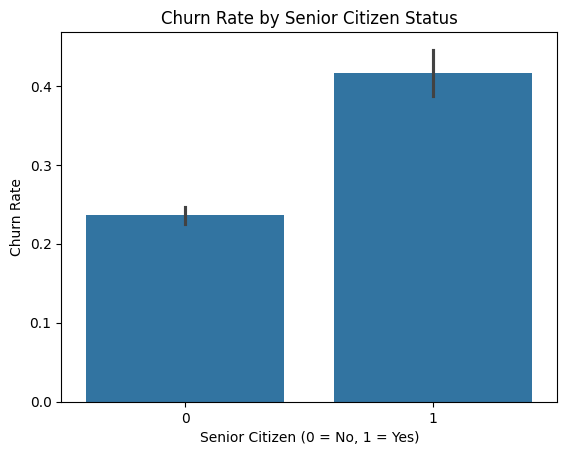

In [54]:
sns.barplot(
    data=df,
    x="SeniorCitizen",
    y="Churn"
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate")
plt.show()

CHURN BY GENDER

In [55]:
gender_churn = (
    df.groupby("gender")["Churn"]
    .mean()
    .mul(100)
)

print(gender_churn)

gender
Female    26.920872
Male      26.160338
Name: Churn, dtype: float64


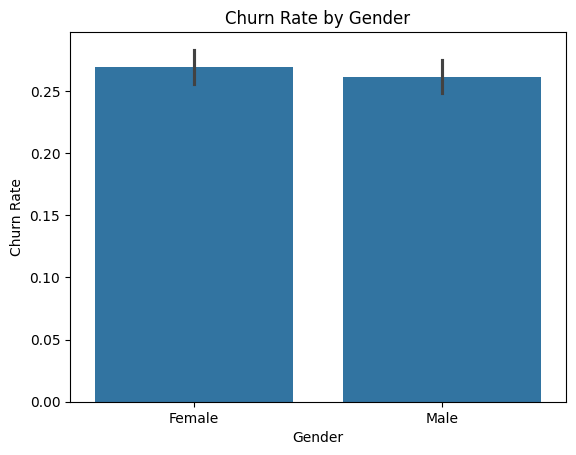

In [56]:
sns.barplot(
    data=df,
    x="gender",
    y="Churn"
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate")
plt.show()

In [63]:
summary = pd.DataFrame({
    "Contract": contract_churn,
})

print("Churn by Contract:")
print(summary)

Churn by Contract:
                 Contract
Contract                 
Month-to-month  42.709677
One year        11.269518
Two year         2.831858


In [64]:
print("Churn by Tenure:")
print(tenure_churn)

print("\nChurn by Internet Service:")
print(internet_churn)

print("\nChurn by Payment Method:")
print(payment_churn)

print("\nChurn by Tech Support:")
print(tech_churn)

print("\nChurn by Online Security:")
print(security_churn)

print("\nChurn by Senior Citizen:")
print(senior_churn)

print("\nChurn by Gender:")
print(gender_churn)

Churn by Tenure:
TenureGroup
0-6 Months      52.937205
7-12 Months     35.886525
13-24 Months    28.710938
25-48 Months    20.388959
49-72 Months     9.513176
Name: Churn, dtype: float64

Churn by Internet Service:
InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64

Churn by Payment Method:
PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64

Churn by Tech Support:
TechSupport
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: Churn, dtype: float64

Churn by Online Security:
OnlineSecurity
No                     41.766724
No internet service     7.404980
Yes                    14.611194
Name: Churn, dtype: float64

Churn by Senior Citizen:
SeniorCitizen
0    23.606168
1    41.681261
Name: Churn, dtype: float64

Churn by Ge

**IDENTIFYING CHURN PATTERNS**

CONTRACT WITH INTERNET SERVICES

In [65]:
contract_internet = (
    df.groupby(["Contract", "InternetService"])["Churn"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(contract_internet)

Contract        InternetService
Month-to-month  Fiber optic        54.605263
                DSL                32.215863
One year        Fiber optic        19.294991
Month-to-month  No                 18.893130
One year        DSL                 9.298246
Two year        Fiber optic         7.226107
One year        No                  2.472527
Two year        DSL                 1.910828
                No                  0.783699
Name: Churn, dtype: float64


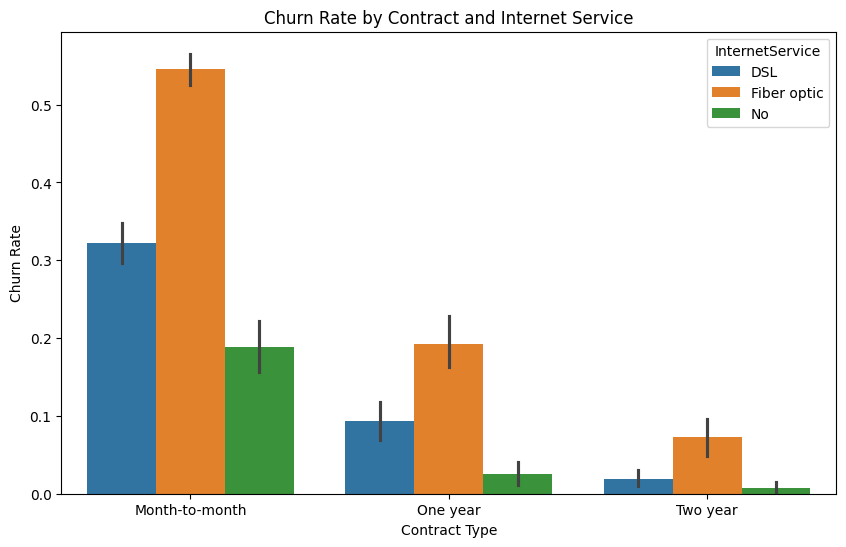

In [66]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Contract",
    y="Churn",
    hue="InternetService"
)

plt.title("Churn Rate by Contract and Internet Service")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")
plt.show()

CONTRACT WITH PAYMENT METHOD

In [67]:
contract_payment = (
    df.groupby(["Contract", "PaymentMethod"])["Churn"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(contract_payment)

Contract        PaymentMethod            
Month-to-month  Electronic check             53.729730
                Bank transfer (automatic)    34.125637
                Credit card (automatic)      32.780847
                Mailed check                 31.578947
One year        Electronic check             18.443804
                Credit card (automatic)      10.301508
                Bank transfer (automatic)     9.718670
Two year        Electronic check              7.738095
One year        Mailed check                  6.824926
Two year        Bank transfer (automatic)     3.368794
                Credit card (automatic)       2.237522
                Mailed check                  0.785340
Name: Churn, dtype: float64


CONTRACT WITH TENURE

In [68]:
tenure_contract = (
    df.groupby(["TenureGroup", "Contract"])["Churn"]
    .mean()
    .mul(100)
)

print(tenure_contract)

TenureGroup   Contract      
0-6 Months    Month-to-month    55.201699
              One year          10.256410
              Two year           0.000000
7-12 Months   Month-to-month    41.996558
              One year          10.588235
              Two year           0.000000
13-24 Months  Month-to-month    37.720488
              One year           8.121827
              Two year           0.000000
25-48 Months  Month-to-month    32.917706
              One year          10.617761
              Two year           2.189781
49-72 Months  Month-to-month    26.023392
              One year          12.933754
              Two year           3.325416
Name: Churn, dtype: float64


/tmp/ipykernel_1337/3944262206.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["TenureGroup", "Contract"])["Churn"]


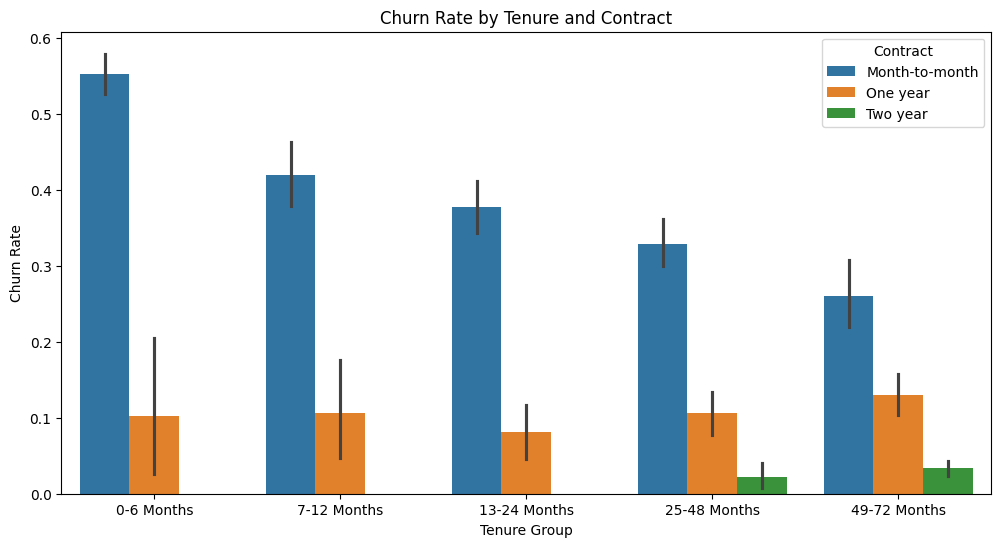

In [69]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="TenureGroup",
    y="Churn",
    hue="Contract"
)

plt.title("Churn Rate by Tenure and Contract")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate")
plt.show()

CUSTOMERS WITH MULTIPLE RISK FACTORS

In [70]:
df["Risk_Factors"] = (
    (df["Contract"] == "Month-to-month").astype(int) +
    (df["tenure"] <= 6).astype(int) +
    (df["MonthlyCharges"] > df["MonthlyCharges"].median()).astype(int) +
    (df["TechSupport"] == "No").astype(int) +
    (df["OnlineSecurity"] == "No").astype(int)
)

In [71]:
print(df["Risk_Factors"].value_counts().sort_index())

Risk_Factors
0    1228
1    1251
2    1420
3    1251
4    1467
5     426
Name: count, dtype: int64


In [73]:
risk_churn = (
    df.groupby("Risk_Factors")["Churn"]
    .mean()
    .mul(100)
)

print(risk_churn)

Risk_Factors
0     1.628664
1     7.833733
2    16.971831
3    29.656275
4    54.873892
5    78.403756
Name: Churn, dtype: float64


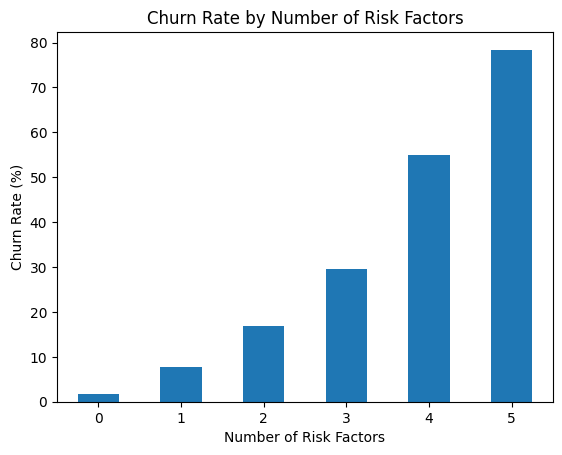

In [74]:
risk_churn.plot(kind="bar")

plt.title("Churn Rate by Number of Risk Factors")
plt.xlabel("Number of Risk Factors")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

**FEATURE ENGINEERING**

In [75]:
df["AverageMonthlySpend"] = (
    df["TotalCharges"] / df["tenure"].replace(0, np.nan)
)

df["AverageMonthlySpend"] = df["AverageMonthlySpend"].fillna(
    df["MonthlyCharges"]
)

In [76]:
df[["tenure", "TotalCharges", "MonthlyCharges", "AverageMonthlySpend"]].head()

,tenure,TotalCharges,MonthlyCharges,AverageMonthlySpend
0,1,29.85,29.85,29.850000
1,34,1889.50,56.95,55.573529
2,2,108.15,53.85,54.075000
3,45,1840.75,42.30,40.905556
4,2,151.65,70.70,75.825000


In [77]:
#HIGH MONTHLY CHARGE CUSTOMER
monthly_median = df["MonthlyCharges"].median()

df["HighMonthlyCharge"] = (
    df["MonthlyCharges"] > monthly_median
).astype(int)

In [78]:
#NEW CUSTOMER
df["NewCustomer"] = (
    df["tenure"] <= 6
).astype(int)

In [79]:
#LONG TERM CUSTOMER
df["LongTermCustomer"] = (
    df["tenure"] >= 24
).astype(int)

In [80]:
# SERVICE COLUMNS
service_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]
df["NumberOfServices"] = 0

for col in service_columns:
    df["NumberOfServices"] += (
        df[col] == "Yes"
    ).astype(int)

In [81]:
df[["customerID", "NumberOfServices"]].head()

,customerID,NumberOfServices
0,7590-VHVEG,1
1,5575-GNVDE,2
2,3668-QPYBK,2
3,7795-CFOCW,3
4,9237-HQITU,0


In [82]:
#RELATIVE CUSTOMER
df["FamilyCustomer"] = (
    (df["Partner"] == "Yes") |
    (df["Dependents"] == "Yes")
).astype(int)

In [83]:
#PAYMENT INDICATOR : AUTOMATIC
df["AutomaticPayment"] = (
    df["PaymentMethod"].str.contains("automatic", case=False, na=False)
).astype(int)

In [84]:
#MONTH TO MONTH RISK INDICATOR
df["MonthToMonth"] = (
    df["Contract"] == "Month-to-month"
).astype(int)

FINAL BUSINESS RISK SCORE

In [86]:
df["BusinessRiskScore"] = (
    df["MonthToMonth"] +
    df["NewCustomer"] +
    df["HighMonthlyCharge"] +
    (df["TechSupport"] == "No").astype(int) +
    (df["OnlineSecurity"] == "No").astype(int)
)

In [87]:
df[
    [
        "customerID",
        "BusinessRiskScore",
        "Churn"
    ]
].head()

,customerID,BusinessRiskScore,Churn
0,7590-VHVEG,4,0
1,5575-GNVDE,1,0
2,3668-QPYBK,3,1
3,7795-CFOCW,0,0
4,9237-HQITU,5,1


**DATA PREPARATION FOR MACHINE LEARNING**

In [88]:
drop_columns = [
    "customerID",
    "Churn",
    "TenureGroup"
]

In [89]:
X = df.drop(columns=drop_columns)

In [90]:
y = df["Churn"]

In [91]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 29)
y shape: (7043,)


In [92]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Risk_Factors', 'AverageMonthlySpend', 'HighMonthlyCharge', 'NewCustomer', 'LongTermCustomer', 'NumberOfServices', 'FamilyCustomer', 'AutomaticPayment', 'MonthToMonth', 'BusinessRiskScore']


In [93]:
print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [94]:
print(y.value_counts(normalize=True) * 100)

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


**SPLIT DATA INTO TRAINING & TESTING**

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [96]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 29)
Testing data: (1409, 29)


ENCODE CATEGORICAL VARIABLES

In [97]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [98]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [99]:
print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (5634, 40)
Processed testing data shape: (1409, 40)


In [167]:
pd.DataFrame(X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed).to_csv("X_train_processed.csv", index=False)

In [168]:
pd.DataFrame(X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed).to_csv("X_test_processed.csv", index=False)

**LOGISTIC REGRESSION MODEL**

In [100]:
from sklearn.linear_model import LogisticRegression

In [101]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


In [102]:
logistic_model.fit(
    X_train_processed,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [103]:
y_pred_logistic = logistic_model.predict(X_test_processed)

y_prob_logistic = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [104]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print("Logistic Regression Results")

print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall   :", recall_score(y_test, y_pred_logistic))
print("F1 Score :", f1_score(y_test, y_pred_logistic))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_logistic))

Logistic Regression Results
Accuracy : 0.8034066713981547
Precision: 0.6632996632996633
Recall   : 0.5267379679144385
F1 Score : 0.587183308494784
ROC-AUC  : 0.8462528094241649


In [105]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



**RANDOM FOREST MODEL**

In [106]:
from sklearn.ensemble import RandomForestClassifier

In [107]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced"
)

In [108]:
rf_model.fit(
    X_train_processed,
    y_train
)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)

In [109]:
y_pred_rf = rf_model.predict(X_test_processed)

y_prob_rf = rf_model.predict_proba(
    X_test_processed
)[:, 1]

In [110]:
print("Random Forest Results")

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Random Forest Results
Accuracy : 0.7679205110007097
Precision: 0.5480572597137015
Recall   : 0.7165775401069518
F1 Score : 0.6210892236384704
ROC-AUC  : 0.8417034798108968


In [111]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.88      0.79      0.83      1035
       Churn       0.55      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



**XGBOOST MODEL**

In [112]:
!pip install xgboost -q

In [113]:
from xgboost import XGBClassifier

In [114]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 2.768561872909699


In [115]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

In [116]:
xgb_model.fit(
    X_train_processed,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [117]:
y_pred_xgb = xgb_model.predict(X_test_processed)

y_prob_xgb = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [118]:
print("XGBoost Results")

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_xgb))

XGBoost Results
Accuracy : 0.759403832505323
Precision: 0.5334608030592735
Recall   : 0.7459893048128342
F1 Score : 0.6220735785953178
ROC-AUC  : 0.837099899248237


In [119]:
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.89      0.76      0.82      1035
       Churn       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



**COMPARING MODELS**

In [120]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803407,0.663300,0.526738,0.587183,0.846253
1,Random Forest,0.767921,0.548057,0.716578,0.621089,0.841703
2,XGBoost,0.759404,0.533461,0.745989,0.622074,0.837100


In [121]:
results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,XGBoost,0.759404,0.533461,0.745989,0.622074,0.837100
1,Random Forest,0.767921,0.548057,0.716578,0.621089,0.841703
0,Logistic Regression,0.803407,0.663300,0.526738,0.587183,0.846253


**COMPARING ROC-AUC GRAPH**

In [122]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(
    y_test,
    y_prob_logistic
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

fpr_xgb, tpr_xgb, _ = roc_curve(
    y_test,
    y_prob_xgb
)

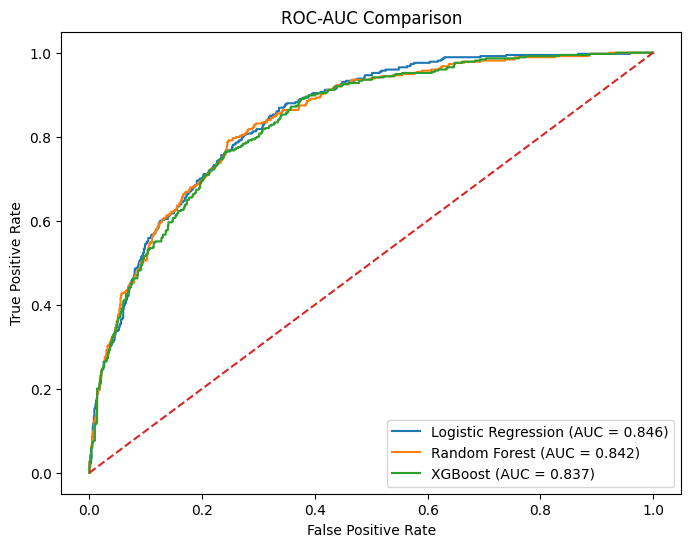

In [123]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_logistic):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})"
)

plt.plot(
    fpr_xgb,
    tpr_xgb,
    label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Comparison")
plt.legend()
plt.show()

**SAVING BEST MODEL**

In [125]:
best_model = xgb_model

print("Selected Model:XGBoost")

Selected Model:XGBoost


In [126]:
import joblib

joblib.dump(
    best_model,
    "customer_churn_model.pkl"
)

joblib.dump(
    preprocessor,
    "customer_churn_preprocessor.pkl"
)

print("Model and preprocessor saved successfully.")

Model and preprocessor saved successfully.


CONFUAION MATRIX

In [127]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_xgb)

print(cm)

[[791 244]
 [ 95 279]]


<Figure size 700x500 with 0 Axes>

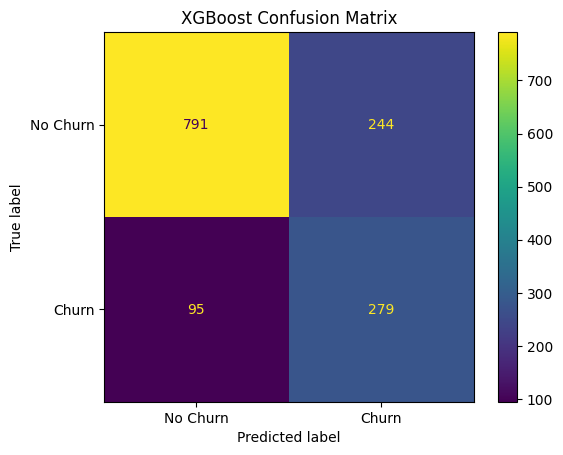

In [128]:
plt.figure(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

**CHURN PREDICTION USING DIFFERENT THRESHOLDS**

In [129]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:

    predictions = (y_prob_xgb >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score
0,0.3,0.465714,0.871658,0.607076
1,0.4,0.495017,0.796791,0.610656
2,0.5,0.533461,0.745989,0.622074
3,0.6,0.576271,0.636364,0.604828
4,0.7,0.647059,0.529412,0.582353


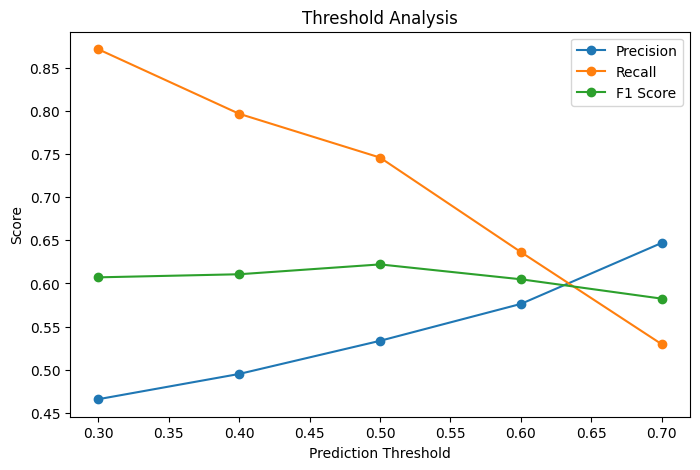

In [130]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Prediction Threshold")
plt.ylabel("Score")
plt.title("Threshold Analysis")
plt.legend()
plt.show()

**COMPLETE EXPLANATION USING SHAP**

In [131]:
!pip install shap -q

In [132]:
import shap

In [133]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 40


In [134]:
explainer = shap.TreeExplainer(xgb_model)

In [135]:
shap_values = explainer.shap_values(X_test_processed)

SHAP SUMMARY CHART

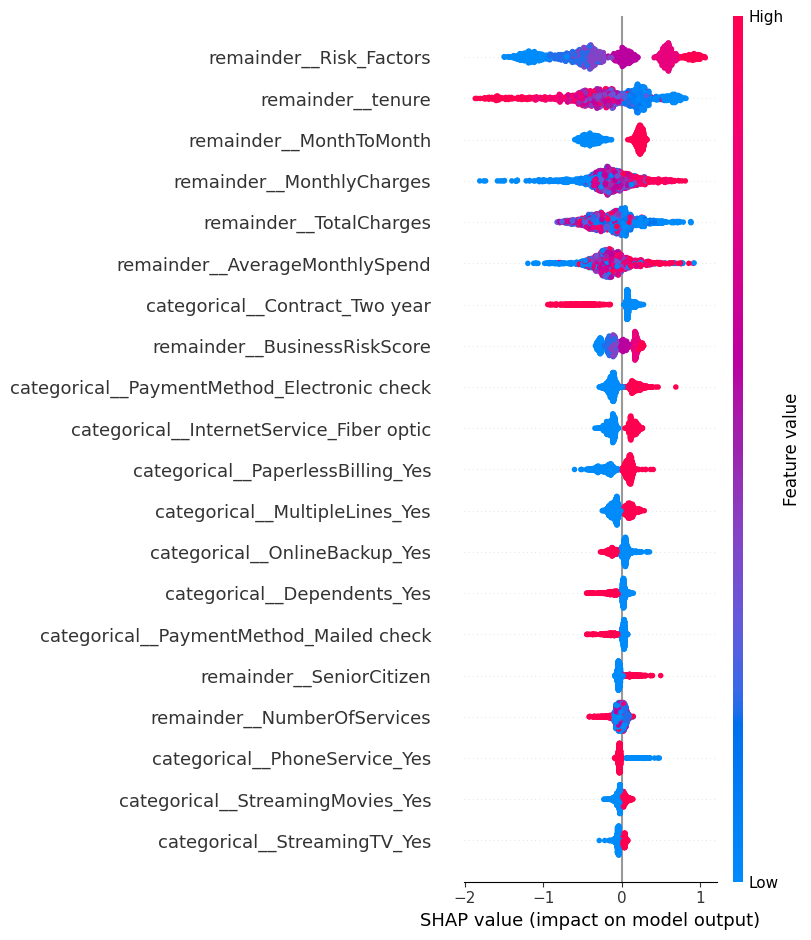

In [136]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names
)

SHAP BAR CHART

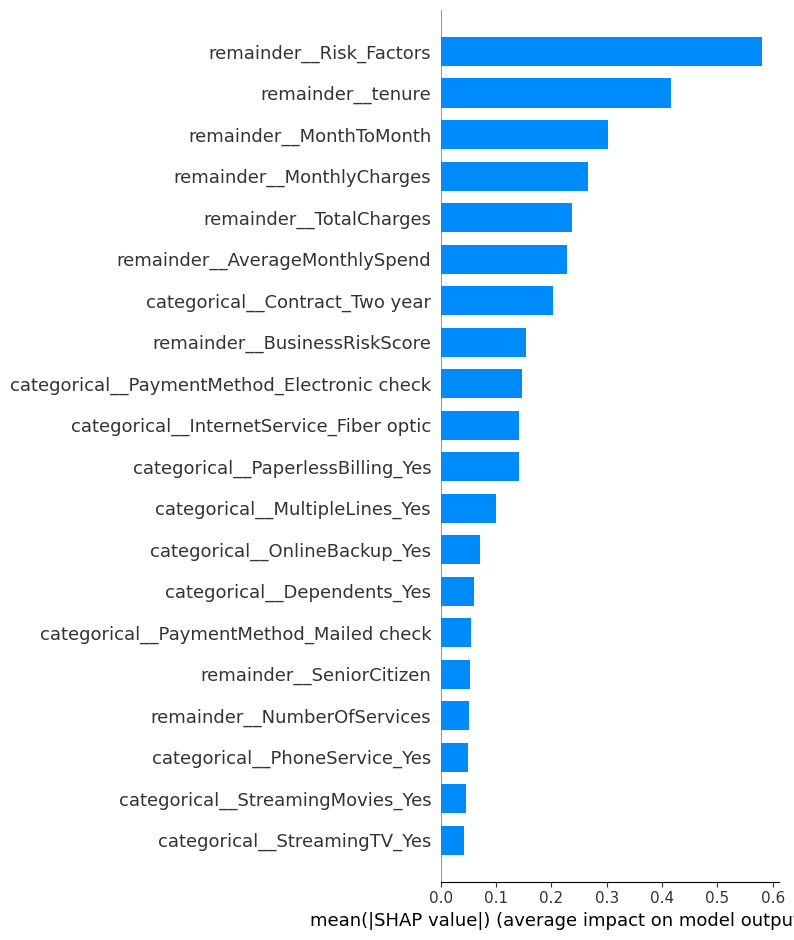

In [137]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    plot_type="bar"
)

EXPLAIN INDIVIDUAL CUSTOMER WHY HIGH/LOW CHURN

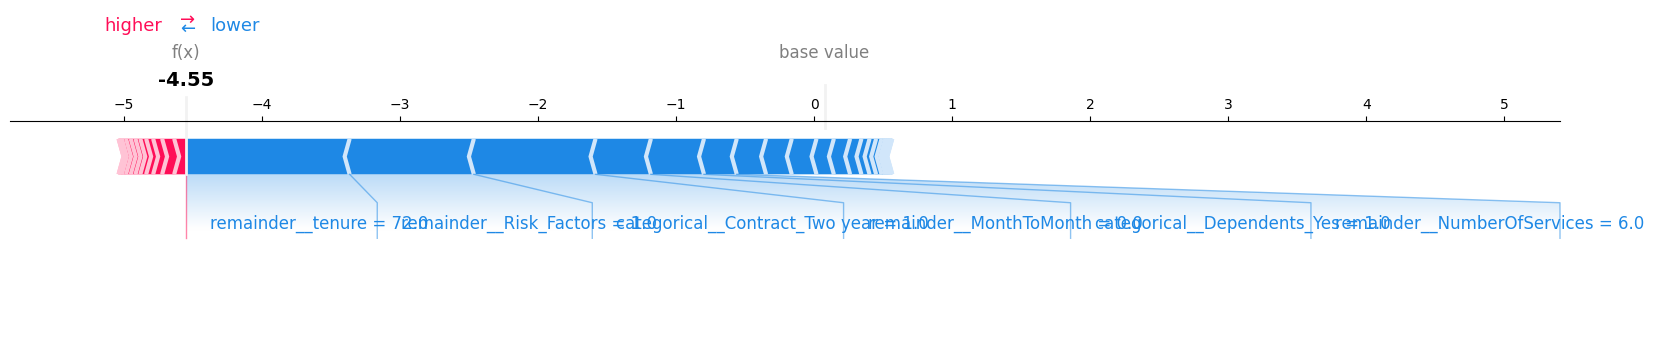

In [138]:
customer_index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    X_test_processed[customer_index],
    feature_names=feature_names,
    matplotlib=True
)

plt.show()

**CUSTOMER CHURN PROBABILITY & RISK RANKING**

In [139]:
test_indices = X_test.index

In [140]:
customer_results = df.loc[
    test_indices,
    [
        "customerID",
        "tenure",
        "Contract",
        "MonthlyCharges",
        "TotalCharges",
        "InternetService",
        "PaymentMethod",
        "TechSupport",
        "OnlineSecurity",
        "Churn"
    ]
].copy()

In [141]:
customer_results["ChurnProbability"] = y_prob_xgb

In [142]:
customer_results["ChurnProbability"] = (
    customer_results["ChurnProbability"] * 100
)

ADDING RISK LEVELS

In [143]:
def risk_level(probability):

    if probability >= 70:
        return "High Risk"

    elif probability >= 40:
        return "Medium Risk"

    else:
        return "Low Risk"

In [144]:
customer_results["RiskLevel"] = (
    customer_results["ChurnProbability"]
    .apply(risk_level)
)

In [145]:
customer_results.head()

,customerID,tenure,Contract,MonthlyCharges,TotalCharges,InternetService,PaymentMethod,TechSupport,OnlineSecurity,Churn,ChurnProbability,RiskLevel
437,4376-KFVRS,72,Two year,114.05,8468.20,Fiber optic,Credit card (automatic),Yes,Yes,0,1.048653,Low Risk
2280,2754-SDJRD,8,Month-to-month,100.15,908.55,Fiber optic,Credit card (automatic),Yes,No,0,92.660316,High Risk
2235,9917-KWRBE,41,One year,78.35,3211.20,DSL,Credit card (automatic),No,Yes,0,18.767443,Low Risk
4460,0365-GXEZS,18,Month-to-month,78.20,1468.75,Fiber optic,Electronic check,Yes,No,0,50.417297,Medium Risk
3761,9385-NXKDA,72,Two year,82.65,5919.35,DSL,Credit card (automatic),No,Yes,0,0.596620,Low Risk


In [146]:
customer_results = customer_results.sort_values(
    by="ChurnProbability",
    ascending=False
)

In [147]:
customer_results.head(10)

,customerID,tenure,Contract,MonthlyCharges,TotalCharges,InternetService,PaymentMethod,TechSupport,OnlineSecurity,Churn,ChurnProbability,RiskLevel
6866,0295-PPHDO,1,Month-to-month,95.45,95.45,Fiber optic,Electronic check,No,No,1,98.094490,High Risk
4585,1069-XAIEM,1,Month-to-month,85.05,85.05,Fiber optic,Electronic check,No,No,1,97.796906,High Risk
3380,5178-LMXOP,1,Month-to-month,95.10,95.10,Fiber optic,Electronic check,No,No,1,97.708237,High Risk
2631,6861-XWTWQ,7,Month-to-month,99.25,665.45,Fiber optic,Electronic check,No,No,1,97.059669,High Risk
6623,9248-OJYKK,1,Month-to-month,76.45,76.45,Fiber optic,Electronic check,No,No,1,96.996475,High Risk
2464,2609-IAICY,1,Month-to-month,77.15,77.15,Fiber optic,Electronic check,No,No,1,96.855232,High Risk
2753,6857-VWJDT,1,Month-to-month,95.65,95.65,Fiber optic,Mailed check,No,No,1,96.772781,High Risk
3727,9057-SIHCH,3,Month-to-month,96.60,291.90,Fiber optic,Electronic check,No,No,1,96.613831,High Risk
1731,8375-DKEBR,1,Month-to-month,69.60,69.60,Fiber optic,Electronic check,No,No,1,96.611671,High Risk
4678,3006-XIMLN,2,Month-to-month,94.20,193.80,Fiber optic,Bank transfer (automatic),No,No,1,96.610992,High Risk


CUSTOMERS COUNT BY RISK LEVEL

In [148]:
risk_distribution = (
    customer_results["RiskLevel"]
    .value_counts()
)

print(risk_distribution)

RiskLevel
Low Risk       807
High Risk      306
Medium Risk    296
Name: count, dtype: int64


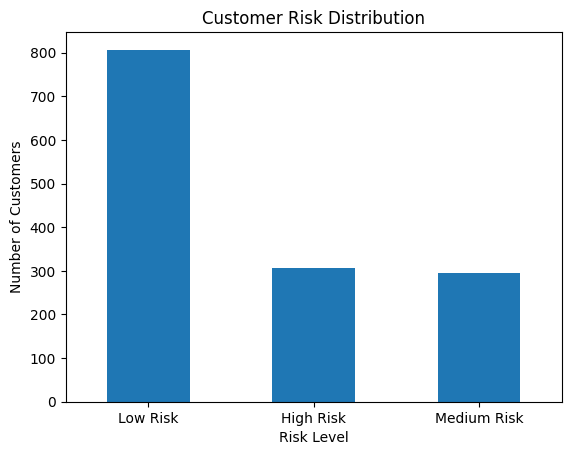

In [149]:
risk_distribution.plot(
    kind="bar"
)

plt.title("Customer Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

**ANALYZING REVENUE AT RISK**

In [150]:
customer_results["ExpectedRevenueAtRisk"] = (
    customer_results["ChurnProbability"] / 100
    * customer_results["TotalCharges"]
)

In [154]:
customer_results[
    [
        "customerID",
        "ChurnProbability",
        "TotalCharges",
        "ExpectedRevenueAtRisk"
    ]
].head(10)

,customerID,ChurnProbability,TotalCharges,ExpectedRevenueAtRisk
6866,0295-PPHDO,98.094490,95.45,93.631188
4585,1069-XAIEM,97.796906,85.05,83.176268
3380,5178-LMXOP,97.708237,95.10,92.920534
2631,6861-XWTWQ,97.059669,665.45,645.883555
6623,9248-OJYKK,96.996475,76.45,74.153805
2464,2609-IAICY,96.855232,77.15,74.723814
2753,6857-VWJDT,96.772781,95.65,92.563168
3727,9057-SIHCH,96.613831,291.90,282.015771
1731,8375-DKEBR,96.611671,69.60,67.241724
4678,3006-XIMLN,96.610992,193.80,187.232105


In [152]:
total_revenue_at_risk = (
    customer_results["ExpectedRevenueAtRisk"]
    .sum()
)

print(
    f"Estimated Revenue at Risk: "
    f"${total_revenue_at_risk:,.2f}"
)

Estimated Revenue at Risk: $832,186.07


In [153]:
high_value_risk = customer_results.sort_values(
    by="ExpectedRevenueAtRisk",
    ascending=False
)

high_value_risk.head(10)

,customerID,tenure,Contract,MonthlyCharges,TotalCharges,InternetService,PaymentMethod,TechSupport,OnlineSecurity,Churn,ChurnProbability,RiskLevel,ExpectedRevenueAtRisk
402,0979-PHULV,69,Month-to-month,99.45,7007.60,Fiber optic,Credit card (automatic),No,No,1,82.778046,High Risk,5800.754528
2282,1587-FKLZB,66,Month-to-month,99.50,6822.15,Fiber optic,Credit card (automatic),No,No,1,80.326591,High Risk,5480.000659
6537,1444-VVSGW,70,One year,115.65,7968.85,Fiber optic,Credit card (automatic),Yes,Yes,1,67.310272,Medium Risk,5363.854742
2860,2452-KDRRH,67,Month-to-month,101.40,6841.05,Fiber optic,Credit card (automatic),No,No,0,77.565247,High Risk,5306.277318
4572,6377-WHAOX,60,Month-to-month,106.15,6411.25,Fiber optic,Electronic check,No,No,0,80.507019,High Risk,5161.506075
807,2798-NYLMZ,71,Two year,108.55,7616.00,Fiber optic,Credit card (automatic),Yes,Yes,0,66.580070,Medium Risk,5070.738060
3411,7056-IMHCC,53,Month-to-month,101.90,5549.40,Fiber optic,Electronic check,No,No,1,89.406418,High Risk,4961.519805
2684,5440-VHLUL,69,One year,105.20,7386.05,Fiber optic,Bank transfer (automatic),Yes,No,0,65.899292,Medium Risk,4867.354850
6181,4937-QPZPO,61,One year,99.90,6241.35,Fiber optic,Electronic check,No,No,0,75.786766,High Risk,4730.117159
3922,6173-GOLSU,67,Month-to-month,94.65,6079.00,Fiber optic,Credit card (automatic),No,No,0,74.624336,High Risk,4536.413371


ADDING PRIORITY LEVELS

In [155]:
def priority_level(row):

    if (
        row["ChurnProbability"] >= 70
        and row["ExpectedRevenueAtRisk"] >= customer_results["ExpectedRevenueAtRisk"].median()
    ):
        return "Priority 1"

    elif row["ChurnProbability"] >= 70:
        return "Priority 2"

    elif row["ChurnProbability"] >= 40:
        return "Priority 3"

    else:
        return "Low Priority"

In [156]:
customer_results["RetentionPriority"] = (
    customer_results.apply(
        priority_level,
        axis=1
    )
)

In [157]:
customer_results[
    [
        "customerID",
        "ChurnProbability",
        "ExpectedRevenueAtRisk",
        "RiskLevel",
        "RetentionPriority"
    ]
].head(10)

,customerID,ChurnProbability,ExpectedRevenueAtRisk,RiskLevel,RetentionPriority
6866,0295-PPHDO,98.094490,93.631188,High Risk,Priority 2
4585,1069-XAIEM,97.796906,83.176268,High Risk,Priority 2
3380,5178-LMXOP,97.708237,92.920534,High Risk,Priority 2
2631,6861-XWTWQ,97.059669,645.883555,High Risk,Priority 1
6623,9248-OJYKK,96.996475,74.153805,High Risk,Priority 2
2464,2609-IAICY,96.855232,74.723814,High Risk,Priority 2
2753,6857-VWJDT,96.772781,92.563168,High Risk,Priority 2
3727,9057-SIHCH,96.613831,282.015771,High Risk,Priority 1
1731,8375-DKEBR,96.611671,67.241724,High Risk,Priority 2
4678,3006-XIMLN,96.610992,187.232105,High Risk,Priority 2


FINAL BUSINESS REPORT

In [158]:
final_customer_risk = customer_results[
    [
        "customerID",
        "tenure",
        "Contract",
        "MonthlyCharges",
        "TotalCharges",
        "InternetService",
        "PaymentMethod",
        "TechSupport",
        "OnlineSecurity",
        "ChurnProbability",
        "RiskLevel",
        "ExpectedRevenueAtRisk",
        "RetentionPriority"
    ]
].copy()

In [159]:
final_customer_risk.to_csv(
    "customer_churn_risk_analysis.csv",
    index=False
)

print("Customer risk analysis saved successfully.")

Customer risk analysis saved successfully.


**CUSTOMER RETENTION RECOMMENDATION SYSTEM**

In [160]:
def retention_recommendation(row):

    recommendations = []

    if row["ChurnProbability"] >= 70:
        if row["Contract"] == "Month-to-month":
            recommendations.append(
                "Offer an incentive to move to a long-term contract"
            )

        if row["TechSupport"] == "No":
            recommendations.append(
                "Offer technical support or a support package"
            )

        if row["OnlineSecurity"] == "No":
            recommendations.append(
                "Offer an online security package"
            )

        if row["MonthlyCharges"] > df["MonthlyCharges"].median():
            recommendations.append(
                "Provide a personalized pricing or loyalty offer"
            )

    if row["RetentionPriority"] == "Priority 1":
        recommendations.append(
            "Assign priority customer-retention intervention"
        )

    if len(recommendations) == 0:
        recommendations.append(
            "Continue regular customer engagement"
        )

    return " | ".join(recommendations)

In [161]:
final_customer_risk["RetentionRecommendation"] = (
    final_customer_risk.apply(
        retention_recommendation,
        axis=1
    )
)

SUMMARY REPORT

In [163]:
total_customers = len(df)

total_churned = df["Churn"].sum()

churn_rate = (
    total_churned / total_customers
) * 100

high_risk_count = (
    final_customer_risk["RiskLevel"] == "High Risk"
).sum()

priority_1_count = (
    final_customer_risk["RetentionPriority"] == "Priority 1"
).sum()

total_revenue_at_risk = (
    final_customer_risk["ExpectedRevenueAtRisk"].sum()
)

print("Total Customers:", total_customers)
print("Churn Rate:", round(churn_rate, 2), "%")
print("High-Risk Customers:", high_risk_count)
print("Priority 1 Customers:", priority_1_count)
print(
    "Estimated Revenue at Risk: $",
    round(total_revenue_at_risk, 2)
)

Total Customers: 7043
Churn Rate: 26.54 %
High-Risk Customers: 306
Priority 1 Customers: 170
Estimated Revenue at Risk: $ 832186.07


In [164]:
business_insights = {
    "Metric": [
        "Overall Churn Rate",
        "High-Risk Customers",
        "Priority 1 Customers",
        "Estimated Revenue at Risk"
    ],

    "Value": [
        f"{churn_rate:.2f}%",
        high_risk_count,
        priority_1_count,
        f"${total_revenue_at_risk:,.2f}"
    ]
}

business_insights = pd.DataFrame(business_insights)

business_insights

,Metric,Value
0,Overall Churn Rate,26.54%
1,High-Risk Customers,306
2,Priority 1 Customers,170
3,Estimated Revenue at Risk,"$832,186.07"


In [165]:
contract_analysis = (
    df.groupby("Contract")["Churn"]
    .agg(["count", "mean"])
    .reset_index()
)

contract_analysis["Churn Rate"] = (
    contract_analysis["mean"] * 100
)

contract_analysis = contract_analysis.drop(
    columns=["mean"]
)

contract_analysis

,Contract,count,Churn Rate
0,Month-to-month,3875,42.709677
1,One year,1473,11.269518
2,Two year,1695,2.831858


In [169]:
import os

os.listdir()

['.config',
 'drive',
 'X_train_processed.csv',
 'customer_churn_cleaned.csv',
 'X_test_processed.csv',
 'customer_churn_model.pkl',
 'customer_churn_risk_analysis.csv',
 'customer_churn_preprocessor.pkl',
 'sample_data']